# Fast Simulation Mode with Internal C++ Engine

Fast mode is available

Internally, it use C++ simulation engine

Users can use this fast mode just like the original pure-Python mode

This is almost compatible.
Exceptions


## Standard usage

Here is a large-scale grid network scenario in Python mode.

simulation setting:
 scenario name: grid_python
 simulation duration:	 7200 s
 number of vehicles:	 60500 veh
 total road length:	 440000 m
 timestep size:	 5 s
 platoon size:		 5 veh
 number of timesteps:	 1440
 number of platoons:	 12100
 number of links:	 440
 number of nodes:	 121
 setup time:		 1.83 s
simulating...
      time| # of vehicles| ave speed| computation time
       0 s|        0 vehs|   0.0 m/s|     0.00 s
     600 s|     8320 vehs|  10.4 m/s|     1.35 s
    1200 s|    15695 vehs|  11.6 m/s|     3.43 s
    1800 s|    19015 vehs|   9.9 m/s|     5.82 s
    2400 s|    21295 vehs|   8.3 m/s|     8.12 s
    3000 s|    24695 vehs|   6.9 m/s|    10.29 s
    3600 s|    30140 vehs|   5.6 m/s|    12.45 s
    4200 s|    24545 vehs|   6.7 m/s|    14.53 s
    4800 s|    16060 vehs|   9.3 m/s|    16.10 s
    5400 s|     5660 vehs|  15.6 m/s|    17.05 s
    6000 s|       70 vehs|  18.9 m/s|    17.27 s
    6600 s|       25 vehs|  18.0 m/s|    17.31 s
    7200 s|        5 vehs|  20.0 m/

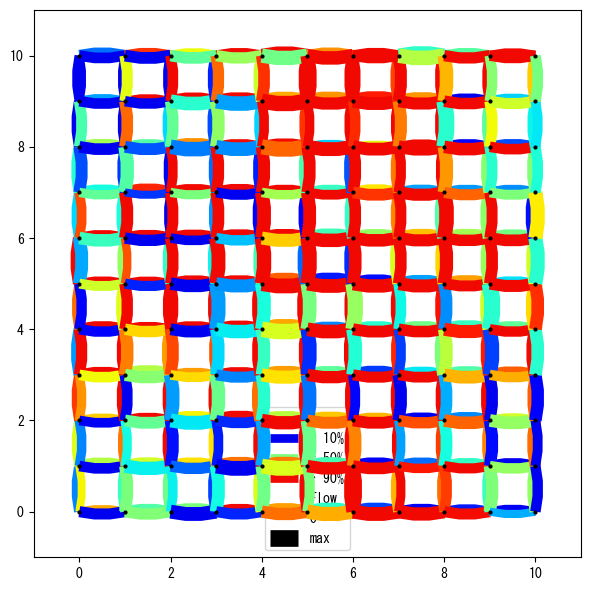

In [2]:
from uxsim import *

# simulation world
W = World(
    name="grid_python",
    deltan=5,
    tmax=7200,
    no_cyclic_routing=True,
    print_mode=1, show_mode=1,
    random_seed=0,
)

# scenario
#automated network generation
#deploy nodes as an imax x jmax grid
imax = 11
jmax = 11
nodes = {}
for i in range(imax):
    for j in range(jmax):
        nodes[i,j] = W.addNode(f"n{(i,j)}", i, j)

#create links between neighborhood nodes
links = {}
for i in range(imax):
    for j in range(jmax):
        if i != imax-1:
            links[i,j,i+1,j] = W.addLink(f"l{(i,j,i+1,j)}", nodes[i,j], nodes[i+1,j], length=1000, free_flow_speed=20, jam_density=0.2)
        if i != 0:
            links[i,j,i-1,j] = W.addLink(f"l{(i,j,i-1,j)}", nodes[i,j], nodes[i-1,j], length=1000, free_flow_speed=20, jam_density=0.2)
        if j != jmax-1:
            links[i,j,i,j+1] = W.addLink(f"l{(i,j,i,j+1)}", nodes[i,j], nodes[i,j+1], length=1000, free_flow_speed=20, jam_density=0.2)
        if j != 0:
            links[i,j,i,j-1] = W.addLink(f"l{(i,j,i,j-1)}", nodes[i,j], nodes[i,j-1], length=1000, free_flow_speed=20, jam_density=0.2)

#generate traffic demand between the boundary nodes
demand_flow = 0.035
demand_duration = 3600
for n1 in [(0,j) for j in range(jmax)]:
    for n2 in [(imax-1,j) for j in range(jmax)]:
        W.adddemand(nodes[n2], nodes[n1], 0, demand_duration, demand_flow)
        W.adddemand(nodes[n1], nodes[n2], 0, demand_duration, demand_flow)
for n1 in [(i,0) for i in range(imax)]:
    for n2 in [(i,jmax-1) for i in range(imax)]:
        W.adddemand(nodes[n2], nodes[n1], 0, demand_duration, demand_flow)
        W.adddemand(nodes[n1], nodes[n2], 0, demand_duration, demand_flow)


# execute simulation
W.exec_simulation()

# visualize
W.analyzer.print_simple_stats()
W.analyzer.network_average(network_font_size=0)

By simply using `cpp=True` option in `W=World(..., cpp=True)`, the fast C++ mode can be enabled.

Simulating...
      time| # of vehicles|  ave speed
       0 s|         0 veh|   0.00 m/s
     720 s|      9890 veh|  14.85 m/s
    1440 s|     16520 veh|  13.28 m/s
    2160 s|     19760 veh|  10.62 m/s
    2880 s|     24105 veh|   8.45 m/s
    3600 s|     29360 veh|   5.87 m/s
    4320 s|     21820 veh|   9.23 m/s
    5040 s|     10640 veh|  14.18 m/s
    5760 s|       760 veh|  19.70 m/s
    6480 s|        85 veh|  20.00 m/s
 simulation finished
results:
 average speed:	 9.7 m/s
 number of completed trips:	 60450 / 60500
 total travel time:		 97694875.0 s
 average travel time of trips:	 1616.1 s
 average delay of trips:	 934.4 s
 delay ratio:			 0.578
 total distance traveled:	 924686250.0 m


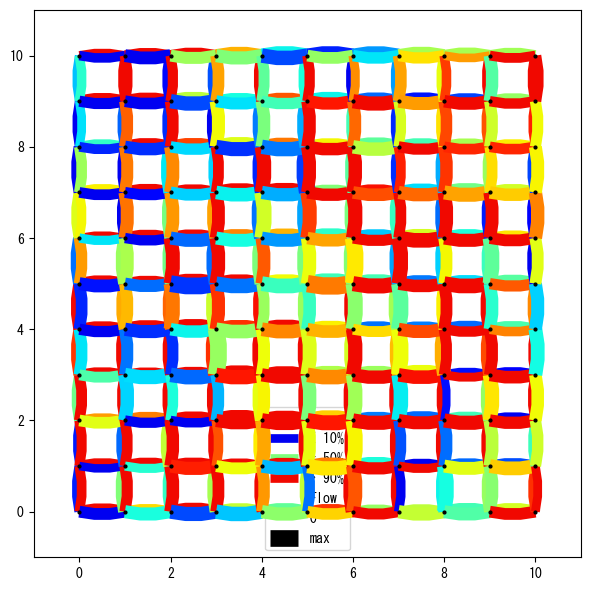

In [6]:
from uxsim import *

# simulation world
W = World(
    name="grid_cpp",
    deltan=5,
    tmax=7200,
    no_cyclic_routing=True,
    print_mode=1, show_mode=1,
    random_seed=0,
    cpp=True #<- Just this option!
)

# scenario
#automated network generation
#deploy nodes as an imax x jmax grid
imax = 11
jmax = 11
nodes = {}
for i in range(imax):
    for j in range(jmax):
        nodes[i,j] = W.addNode(f"n{(i,j)}", i, j)

#create links between neighborhood nodes
links = {}
for i in range(imax):
    for j in range(jmax):
        if i != imax-1:
            links[i,j,i+1,j] = W.addLink(f"l{(i,j,i+1,j)}", nodes[i,j], nodes[i+1,j], length=1000, free_flow_speed=20, jam_density=0.2)
        if i != 0:
            links[i,j,i-1,j] = W.addLink(f"l{(i,j,i-1,j)}", nodes[i,j], nodes[i-1,j], length=1000, free_flow_speed=20, jam_density=0.2)
        if j != jmax-1:
            links[i,j,i,j+1] = W.addLink(f"l{(i,j,i,j+1)}", nodes[i,j], nodes[i,j+1], length=1000, free_flow_speed=20, jam_density=0.2)
        if j != 0:
            links[i,j,i,j-1] = W.addLink(f"l{(i,j,i,j-1)}", nodes[i,j], nodes[i,j-1], length=1000, free_flow_speed=20, jam_density=0.2)

#generate traffic demand between the boundary nodes
demand_flow = 0.035
demand_duration = 3600
for n1 in [(0,j) for j in range(jmax)]:
    for n2 in [(imax-1,j) for j in range(jmax)]:
        W.adddemand(nodes[n2], nodes[n1], 0, demand_duration, demand_flow)
        W.adddemand(nodes[n1], nodes[n2], 0, demand_duration, demand_flow)
for n1 in [(i,0) for i in range(imax)]:
    for n2 in [(i,jmax-1) for i in range(imax)]:
        W.adddemand(nodes[n2], nodes[n1], 0, demand_duration, demand_flow)
        W.adddemand(nodes[n1], nodes[n2], 0, demand_duration, demand_flow)


# execute simulation
W.exec_simulation()

# visualize
W.analyzer.print_simple_stats()
W.analyzer.network_average(network_font_size=0)

You can see that this is extremely faster than the original Python mode.
The simulation results are basically the same, although there are slight discrepancy due to the difference in the random number generators of Python and C++.

We can also access the internal objects (e.g., `Vehicle`) of UXsim just like pure Python objects.

In [17]:
veh = W.VEHICLES["0"]   #get Vehicle instance
print(type(veh))        #this is actually C++ object
print(veh.orig)         #but, you can access to its variables as in pure-Python mode
print(veh.travel_time)
print(veh.traveled_route())

<class 'uxsim.uxsim_cpp_wrapper.CppVehicle'>
<Node n(10, 0)>
525.0
(<Route : ['l(10, 0, 9, 0)', 'l(9, 0, 8, 0)', 'l(8, 0, 7, 0)', 'l(7, 0, 6, 0)', 'l(6, 0, 5, 0)', 'l(5, 0, 4, 0)', 'l(4, 0, 3, 0)', 'l(3, 0, 2, 0)', 'l(2, 0, 1, 0)', 'l(1, 0, 0, 0)']>, [np.float64(145.0), np.float64(195.0), np.float64(245.0), np.float64(295.0), np.float64(345.0), np.float64(395.0), np.float64(455.0), np.float64(520.0), np.float64(570.0), np.float64(620.0), np.float64(665.0)])


## Dynamic Traffic Assignment with C++ mode

The Dynamic Traffic Assignment (DTA) solvers are also accelerated by C++ mode.

To be written...

## Benchmark

Here is a benchmark result using [this benchmark code](https://github.com/toruseo/UXsim/blob/main/demos_and_examples/example_28en_benchmark_cpp_mode.py) with v1.14.0b7. (to be updated to larger seeds with the latest version).
The speed is significantly faster, and the results are statistically very similar.

### Small & Large scenarios (mean ± std, 5 seeds)

| Scenario  | Mode   | Elapsed (s)   | Total Travel Time      | Average Delay | Completed Trips |
| --------- | ------ | -------------:| ----------------------:| -------------:| ---------------:|
| **small** | Python | 0.037 ± 0.020 | 118,760 ± 475          | 61.6 ± 0.6    | 735 ± 0         |
| **small** | C++    | 0.007 ± 0.000 | 118,715 ± 648          | 61.5 ± 0.9    | 735 ± 0         |
| **large** | Python | 18.53 ± 0.88  | 96,310,930 ± 4,204,547 | 910.7 ± 69.4  | 60,478 ± 17     |
| **large** | C++    | 0.73 ± 0.04   | 93,446,565 ± 5,891,922 | 863.2 ± 97.6  | 60,484 ± 19     |

### DUE/DSO scenario (mean ± std, 5 seeds)

| Mode   | Total Elapsed (s) | DUO TTT             | DUE TTT             | DSO TTT            |
| ------ | -----------------:| -------------------:| -------------------:| ------------------:|
| Python | 125.4 ± 4.9       | 7,188,820 ± 226,645 | 6,032,420 ± 88,571  | 5,280,500 ± 29,523 |
| C++    | 10.7 ± 0.3        | 7,018,500 ± 175,621 | 5,982,680 ± 65,697  | 5,297,100 ± 38,114 |

### Speedup (Python / C++)

- **small**: 5.44x
- **large**: 25.36x
- **DUE/DSO**: 11.69x

### Link-level accuracy: Python vs C++

DUE metrics are based on average link values over the last 20 iterations. DSO metrics are based on the iteration with the minimum total travel time.

#### Per-seed (mean ± std, 5 seeds)

| Scenario  | Metric         |          Corr |          MAE |
| --------- | -------------- | -------------:| ------------:|
| **small** | traffic_volume | 0.995 ± 0.008 |  9.3 ± 12.80 |
| **small** | delay_ratio    | 0.660 ± 0.482 |  0.39 ± 0.46 |
| **large** | traffic_volume | 0.352 ± 0.065 | 292.3 ± 9.10 |
| **large** | delay_ratio    | 0.303 ± 0.097 |  0.39 ± 0.03 |
| **DUO**   | traffic_volume | 0.979 ± 0.006 |  44.5 ± 4.70 |
| **DUO**   | delay_ratio    | 0.867 ± 0.019 |  0.13 ± 0.02 |
| **DUE**   | traffic_volume | 0.952 ± 0.018 | 67.1 ± 12.90 |
| **DUE**   | delay_ratio    | 0.812 ± 0.046 |  0.16 ± 0.02 |
| **DSO**   | traffic_volume | 0.961 ± 0.009 |  64.0 ± 6.90 |
| **DSO**   | delay_ratio    | 0.750 ± 0.037 |  0.14 ± 0.02 |

#### Seed-averaged (5-seed mean vs 5-seed mean)

| Scenario  | Metric         |  Corr |    MAE |
| --------- | -------------- | -----:| ------:|
| **small** | traffic_volume | 0.998 |   9.3  |
| **small** | delay_ratio    | 0.810 |  0.39  |
| **large** | traffic_volume | 0.737 | 129.6  |
| **large** | delay_ratio    | 0.721 |  0.17  |
| **DUO**   | traffic_volume | 0.996 |  21.6  |
| **DUO**   | delay_ratio    | 0.965 |  0.08  |
| **DUE**   | traffic_volume | 0.994 |  25.2  |
| **DUE**   | delay_ratio    | 0.968 |  0.07  |
| **DSO**   | traffic_volume | 0.989 |  34.5  |
| **DSO**   | delay_ratio    | 0.936 |  0.08  |
